In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

In [6]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (7043, 21)


In [7]:
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
# Drop missing rows
df = df.dropna()

In [9]:
# Drop irrelevant column
df = df.drop("customerID", axis=1)

In [10]:
# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [11]:
# after cleaning steps
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7032, 20)


## Exploratory Data Analysis

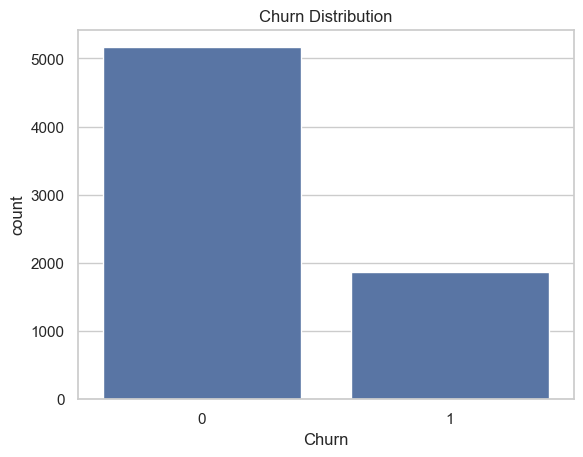

In [12]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

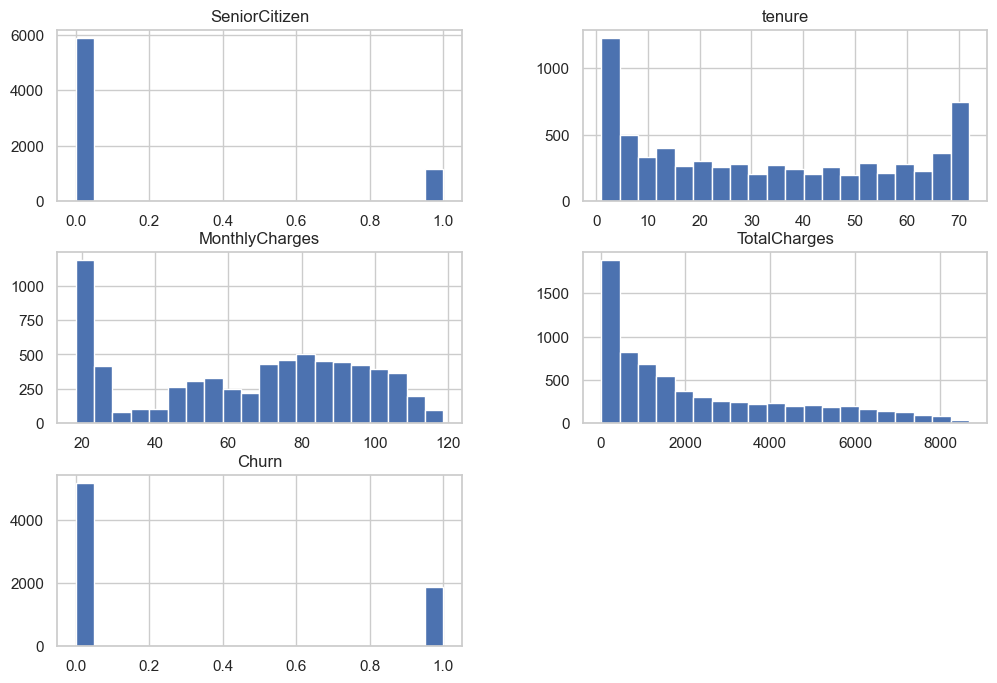

In [13]:
df.hist(bins=20, figsize=(12,8))
plt.show()

### Feature Relationships and Insights

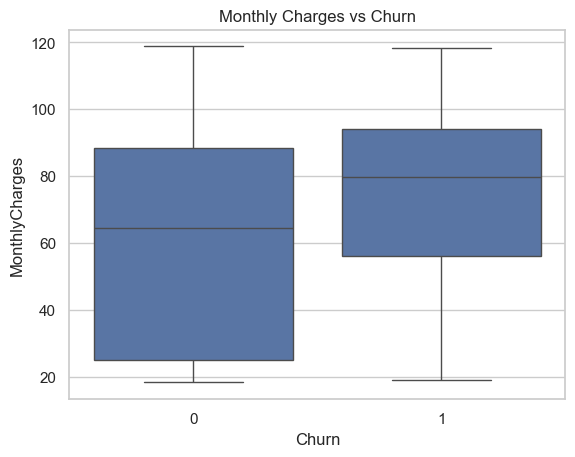

In [14]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

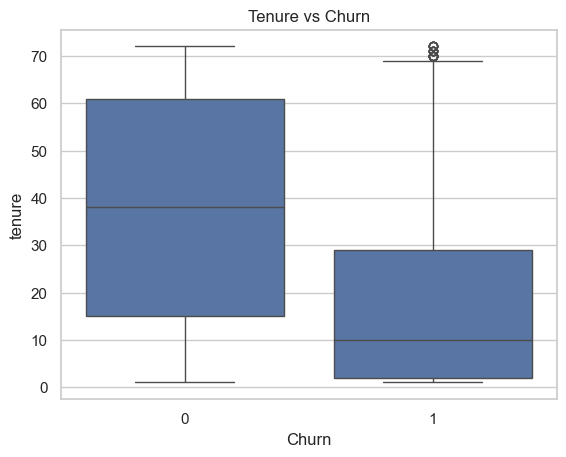

In [15]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

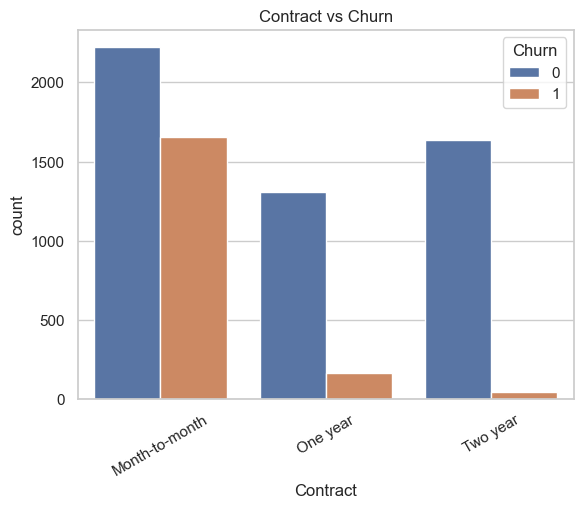

In [16]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.title("Contract vs Churn")
plt.show()

In [17]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [18]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.650010,61.307408,2555.344141
1,17.979133,74.441332,1531.796094


In [19]:
df.groupby("Contract")["Churn"].mean() * 100

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

In [20]:
df.groupby("InternetService")["Churn"].mean() * 100

InternetService
DSL            18.998344
Fiber optic    41.892765
No              7.434211
Name: Churn, dtype: float64

In [21]:
df.groupby("PaymentMethod")["Churn"].mean() * 100

PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.285412
Mailed check                 19.201995
Name: Churn, dtype: float64

In [22]:
df.groupby("TechSupport")["Churn"].mean() * 100

TechSupport
No                     41.647465
No internet service     7.434211
Yes                    15.196078
Name: Churn, dtype: float64

In [23]:
# Churn rate %
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [24]:
# Group churn rate
contract_churn = df.groupby("Contract")["Churn"].mean() * 100
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


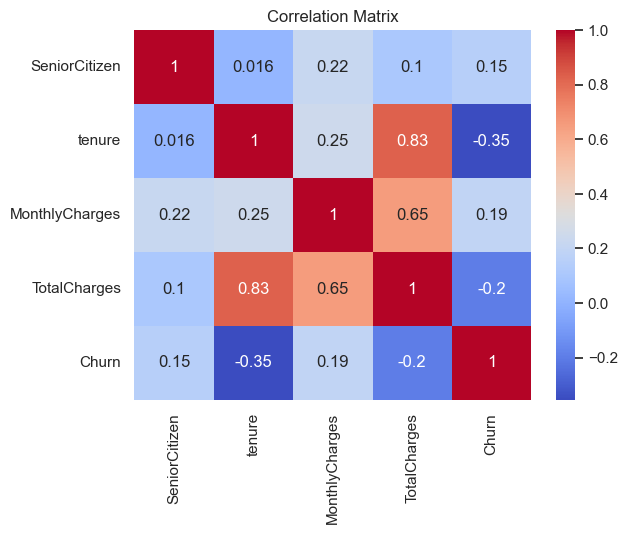

In [25]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

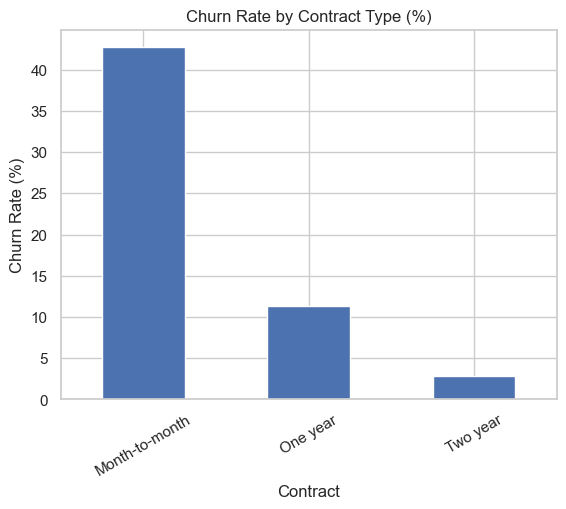

In [26]:
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

## Feature Importance Analysis

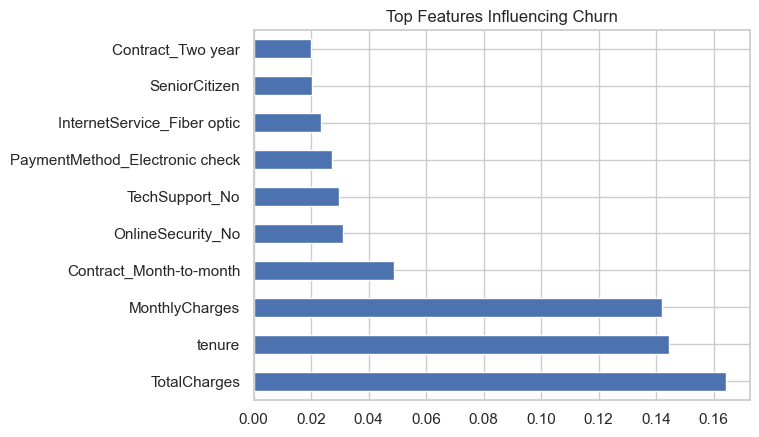

In [27]:
from sklearn.ensemble import RandomForestClassifier

X = pd.get_dummies(df.drop("Churn", axis=1))
y = df["Churn"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind="barh")
plt.title("Top Features Influencing Churn")
plt.show()

In [28]:
df.to_csv("clean_dataset.csv", index=False)

## Key Insights

### 1. Overall Churn Rate
Approximately **26.58% of customers have churned**, while **73.42% have remained**, indicating that although most customers stay, a significant portion still leaves the service.

---

### 2. Tenure and Customer Retention
Customers who churn have a significantly lower average tenure (**17.98 months**) compared to those who remain (**37.65 months**).  
This suggests that newer customers are far more likely to leave early, making early-stage retention critical.

---

### 3. Monthly Charges and Churn
Churned customers have a higher average monthly charge (**R74.44**) compared to retained customers (**R61.31**).  
This indicates that higher pricing may contribute to customer dissatisfaction and increased churn risk.

---

### 4. Contract Type Impact
Contract type has a strong influence on churn:
- **Month-to-month:** 42.71% churn rate  
- **One-year:** 11.28%  
- **Two-year:** 2.85%  

Customers on month-to-month contracts are significantly more likely to churn, while long-term contracts greatly improve retention.

---

### 5. Internet Service Type
Churn rates vary significantly by internet service:
- **Fiber optic:** 41.89%  
- **DSL:** 19.00%  
- **No internet service:** 7.43%  

Customers using fiber optic services show the highest churn, possibly due to higher costs or service expectations.

---

### 6. Payment Method Influence
Payment method also affects churn:
- **Electronic check:** 45.29% (highest)  
- **Bank transfer (automatic):** 16.73%  
- **Credit card (automatic):** 15.25%  
- **Mailed check:** 19.20%  

Customers using electronic checks are far more likely to churn, suggesting a link between payment behavior and retention.

---

### 7. Technical Support and Churn
Technical support availability plays a key role:
- **No tech support:** 41.65% churn  
- **With tech support:** 15.20% churn  
- **No internet service:** 7.43%  

Customers without technical support are almost three times more likely to churn, highlighting the importance of customer support services.

---

## Business Recommendations

- Encourage customers to switch to long-term contracts to improve retention  
- Provide early engagement strategies for new customers  
- Review pricing strategies for high monthly charge customers  
- Investigate issues related to fiber optic services  
- Promote automatic payment methods over electronic checks  
- Improve access to and awareness of technical support services